# Airfare Pricing and Purchase-Timing Analysis

## Business Problem

Air travelers often lack clear information about how booking timing, airline,
route, cabin class, and itinerary characteristics affect ticket prices. This
project analyzes 300,153 airfare observations from major Indian domestic routes
to identify key price drivers, estimate ticket prices, and provide practical
purchase-timing insights for travelers.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [7]:
df = pd.read_csv("/Clean_Dataset.csv")

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows: 300,153
Columns: 12


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [8]:
df = df.drop(columns=["Unnamed: 0"])

print(f"Rows: {df.shape[0]:,}")
print(f"Columns after removing index: {df.shape[1]}")

Rows: 300,153
Columns after removing index: 11


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [10]:
quality_check = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "unique_values": df.nunique()
})

quality_check

,data_type,missing_values,unique_values
airline,object,0,6
flight,object,0,1561
source_city,object,0,6
departure_time,object,0,6
stops,object,0,3
arrival_time,object,0,6
destination_city,object,0,6
class,object,0,2
duration,float64,0,476
days_left,int64,0,49


In [11]:
print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Missing values: {df.isna().sum().sum():,}")
print(f"Non-positive prices: {(df['price'] <= 0).sum():,}")
print(f"Non-positive durations: {(df['duration'] <= 0).sum():,}")
print(f"Same source and destination: {(df['source_city'] == df['destination_city']).sum():,}")

Duplicate rows: 0
Missing values: 0
Non-positive prices: 0
Non-positive durations: 0
Same source and destination: 0


In [12]:
df["route"] = df["source_city"] + " → " + df["destination_city"]

df["days_left_group"] = pd.cut(
    df["days_left"],
    bins=[0, 7, 14, 21, 30, 40, 49],
    labels=["1–7", "8–14", "15–21", "22–30", "31–40", "41–49"]
)

df[["route", "days_left", "days_left_group"]].head()

,route,days_left,days_left_group
0,Delhi → Mumbai,1,1–7
1,Delhi → Mumbai,1,1–7
2,Delhi → Mumbai,1,1–7
3,Delhi → Mumbai,1,1–7
4,Delhi → Mumbai,1,1–7


## Exploratory Data Analysis

### Question 1: How does advance booking time relate to airfare?

Because business-class fares are substantially higher than economy-class fares,
the analysis compares booking-window patterns separately by cabin class to avoid
confounding the relationship between `days_left` and ticket price.

In [13]:
booking_window_summary = (
    df.groupby(
        ["class", "days_left_group"],
        observed=True
    )
    .agg(
        number_of_flights=("price", "size"),
        average_price=("price", "mean"),
        median_price=("price", "median")
    )
    .reset_index()
)

booking_window_summary["average_price"] = (
    booking_window_summary["average_price"].round(0)
)

booking_window_summary["median_price"] = (
    booking_window_summary["median_price"].round(0)
)

booking_window_summary

,class,days_left_group,number_of_flights,average_price,median_price
0,Business,1–7,10548,56745.0,56040.0
1,Business,8–14,13772,52693.0,53209.0
2,Business,15–21,13846,52288.0,53164.0
3,Business,22–30,17982,52002.0,53152.0
4,Business,31–40,19978,51726.0,52715.0
5,Business,41–49,17361,51559.0,52726.0
6,Economy,1–7,21565,11634.0,11248.0
7,Economy,8–14,29033,10048.0,9945.0
8,Economy,15–21,31305,6009.0,5499.0
9,Economy,22–30,40441,5261.0,5094.0


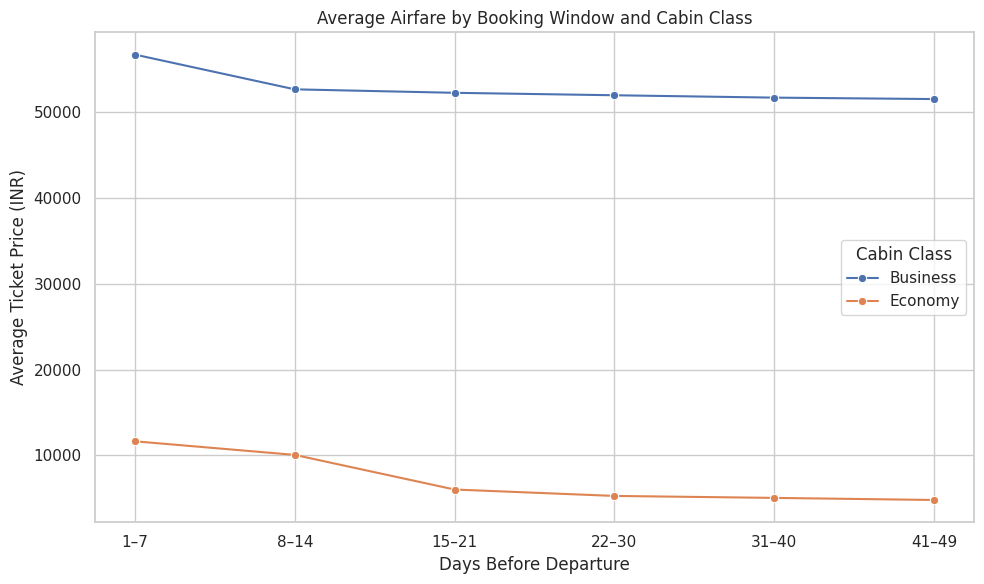

In [14]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=booking_window_summary,
    x="days_left_group",
    y="average_price",
    hue="class",
    marker="o"
)

plt.title("Average Airfare by Booking Window and Cabin Class")
plt.xlabel("Days Before Departure")
plt.ylabel("Average Ticket Price (INR)")
plt.legend(title="Cabin Class")
plt.tight_layout()
plt.show()

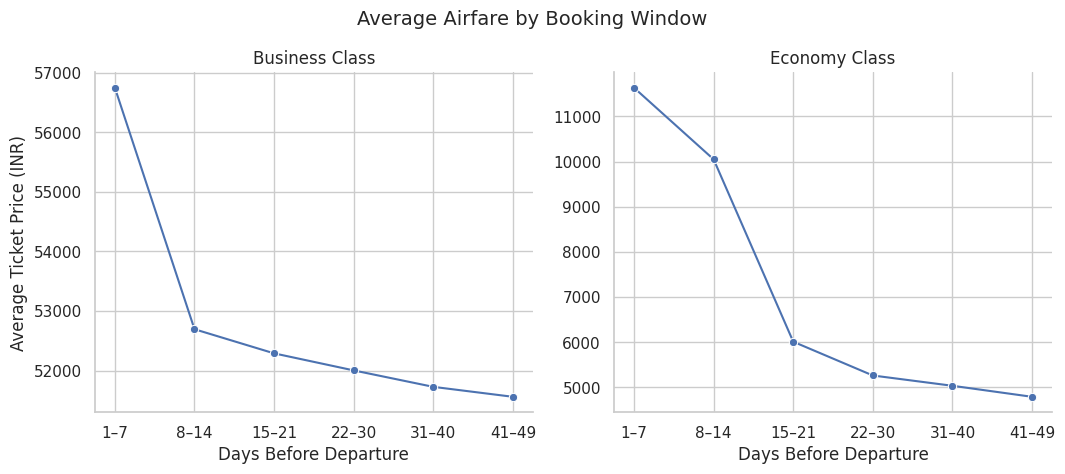

In [15]:
g = sns.relplot(
    data=booking_window_summary,
    x="days_left_group",
    y="average_price",
    col="class",
    kind="line",
    marker="o",
    facet_kws={"sharey": False},
    height=4.5,
    aspect=1.2
)

g.set_axis_labels(
    "Days Before Departure",
    "Average Ticket Price (INR)"
)

g.set_titles("{col_name} Class")
g.fig.suptitle(
    "Average Airfare by Booking Window",
    y=1.05,
    fontsize=14
)

plt.show()

In [16]:
early_booking = (
    booking_window_summary[
        booking_window_summary["days_left_group"] == "41–49"
    ]
    .set_index("class")["average_price"]
)

last_minute = (
    booking_window_summary[
        booking_window_summary["days_left_group"] == "1–7"
    ]
    .set_index("class")["average_price"]
)

booking_premium = (
    (last_minute - early_booking) / early_booking * 100
).round(1)

booking_comparison = pd.DataFrame({
    "41–49 Days Before Departure": early_booking,
    "1–7 Days Before Departure": last_minute,
    "Last-Minute Premium (%)": booking_premium
})

booking_comparison

,41–49 Days Before Departure,1–7 Days Before Departure,Last-Minute Premium (%)
class,,,
Business,51559.0,56745.0,10.1
Economy,4789.0,11634.0,142.9


#### Key Finding

Booking timing is associated with substantially different pricing patterns
across cabin classes. Economy fares averaged INR 11,634 when booked 1–7 days
before departure, compared with INR 4,789 when booked 41–49 days in advance,
representing a 142.9% last-minute premium. Business-class fares increased more
moderately, from INR 51,559 to INR 56,745, a 10.1% premium.

The results suggest that advance booking is especially important for
price-sensitive economy travelers, while business-class pricing is comparatively
stable across booking windows.

### Question 2: How do airfares differ across airlines and cabin classes?

This analysis compares airline pricing separately by cabin class because the
availability of economy and business products differs across carriers. Both
average and median fares are examined to reduce the risk of drawing conclusions
from a small number of unusually expensive tickets.

In [17]:
airline_class_counts = pd.crosstab(
    df["airline"],
    df["class"]
)

airline_class_counts

class,Business,Economy
airline,,
AirAsia,0,16098
Air_India,32898,47994
GO_FIRST,0,23173
Indigo,0,43120
SpiceJet,0,9011
Vistara,60589,67270


In [18]:
airline_price_summary = (
    df.groupby(
        ["class", "airline"],
        observed=True
    )
    .agg(
        number_of_flights=("price", "size"),
        average_price=("price", "mean"),
        median_price=("price", "median")
    )
    .reset_index()
)

airline_price_summary["average_price"] = (
    airline_price_summary["average_price"].round(0)
)

airline_price_summary["median_price"] = (
    airline_price_summary["median_price"].round(0)
)

airline_price_summary = airline_price_summary.sort_values(
    ["class", "average_price"],
    ascending=[True, False]
)

airline_price_summary

,class,airline,number_of_flights,average_price,median_price
1,Business,Vistara,60589,55477.0,56588.0
0,Business,Air_India,32898,47131.0,49613.0
7,Economy,Vistara,67270,7807.0,6461.0
3,Economy,Air_India,47994,7314.0,6082.0
6,Economy,SpiceJet,9011,6179.0,5654.0
4,Economy,GO_FIRST,23173,5652.0,5336.0
5,Economy,Indigo,43120,5324.0,4453.0
2,Economy,AirAsia,16098,4091.0,3276.0


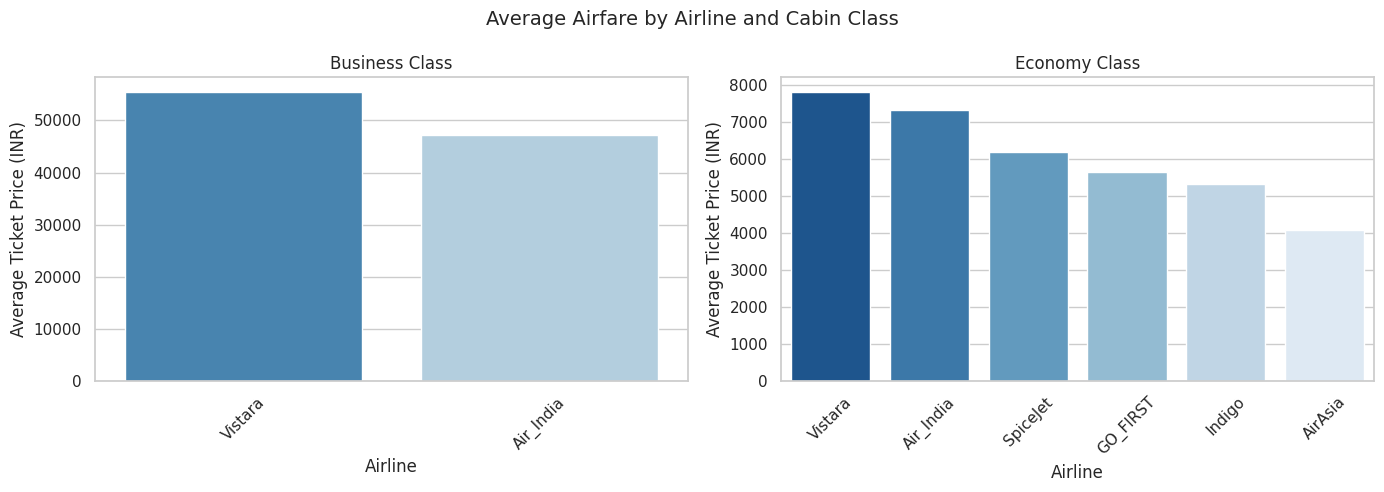

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cabin_class in zip(axes, ["Business", "Economy"]):
    plot_data = (
        airline_price_summary[
            airline_price_summary["class"] == cabin_class
        ]
        .sort_values("average_price", ascending=False)
    )

    sns.barplot(
        data=plot_data,
        x="airline",
        y="average_price",
        hue="airline",
        palette="Blues_r",
        legend=False,
        ax=ax
    )

    ax.set_title(f"{cabin_class} Class")
    ax.set_xlabel("Airline")
    ax.set_ylabel("Average Ticket Price (INR)")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle(
    "Average Airfare by Airline and Cabin Class",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [20]:
airline_extremes = (
    airline_price_summary
    .sort_values("average_price")
    .groupby("class", observed=True)
    .agg(
        lowest_price_airline=("airline", "first"),
        lowest_average_price=("average_price", "first"),
        highest_price_airline=("airline", "last"),
        highest_average_price=("average_price", "last")
    )
)

airline_extremes["price_gap_percent"] = (
    (
        airline_extremes["highest_average_price"]
        - airline_extremes["lowest_average_price"]
    )
    / airline_extremes["lowest_average_price"]
    * 100
).round(1)

airline_extremes

,lowest_price_airline,lowest_average_price,highest_price_airline,highest_average_price,price_gap_percent
class,,,,,
Business,Air_India,47131.0,Vistara,55477.0,17.7
Economy,AirAsia,4091.0,Vistara,7807.0,90.8


#### Key Finding

Business-class observations were available only for Vistara and Air India.
Vistara recorded the higher average business-class fare at INR 55,477, which
was 17.7% above Air India's average of INR 47,131.

Economy fares varied more substantially across the six carriers. AirAsia had
the lowest observed average economy fare at INR 4,091, while Vistara had the
highest at INR 7,807, representing a 90.8% difference.

These results describe observed price differences rather than identical-flight
comparisons. Differences in routes, stops, flight duration, departure time, and
booking windows may partly explain the variation and will be considered in the
predictive model.

### Question 3: How does the number of stops relate to airfare?

This analysis compares nonstop, one-stop, and multi-stop itineraries separately
by cabin class to examine whether travelers pay a premium for more direct
flights.

In [22]:
stops_price_summary = (
    df.groupby(
        ["class", "stops"],
        observed=True
    )
    .agg(
        number_of_flights=("price", "size"),
        average_price=("price", "mean"),
        median_price=("price", "median"),
        average_duration=("duration", "mean")
    )
    .reset_index()
)

stops_price_summary[
    ["average_price", "median_price", "average_duration"]
] = stops_price_summary[
    ["average_price", "median_price", "average_duration"]
].round(1)

stops_price_summary

,class,stops,number_of_flights,average_price,median_price,average_duration
0,Business,one,84302,54687.4,54608.0,14.8
1,Business,two_or_more,1083,70127.7,68743.0,14.4
2,Business,zero,8102,27846.3,27864.0,2.3
3,Economy,one,166561,6812.9,5937.0,12.8
4,Economy,two_or_more,12203,9142.3,8012.0,15.4
5,Economy,zero,27902,4012.6,3531.0,2.2


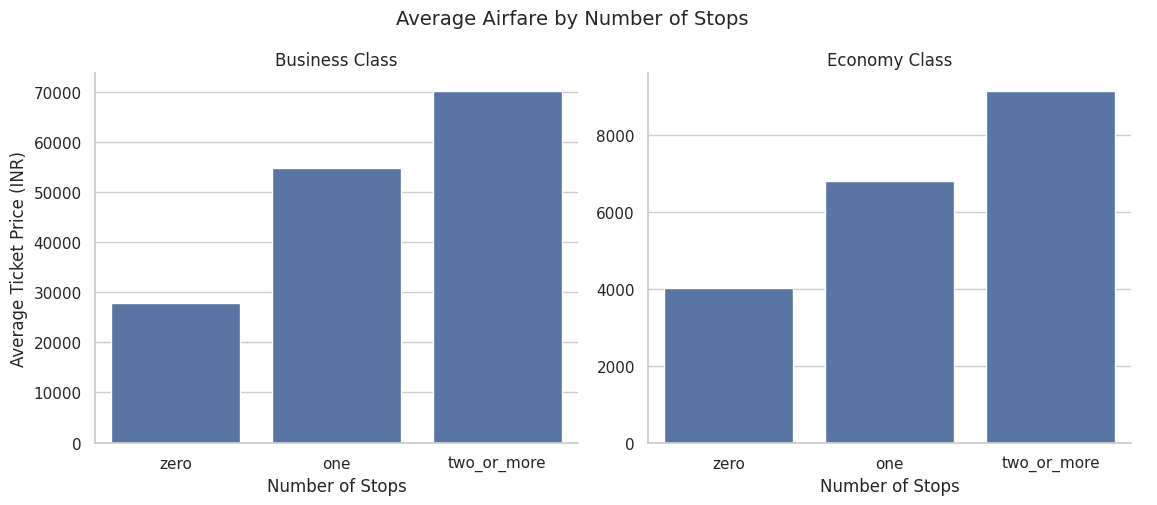

In [23]:
stops_order = ["zero", "one", "two_or_more"]

g = sns.catplot(
    data=stops_price_summary,
    x="stops",
    y="average_price",
    col="class",
    kind="bar",
    order=stops_order,
    sharey=False,
    height=4.8,
    aspect=1.2
)

g.set_axis_labels(
    "Number of Stops",
    "Average Ticket Price (INR)"
)

g.set_titles("{col_name} Class")
g.fig.suptitle(
    "Average Airfare by Number of Stops",
    y=1.05,
    fontsize=14
)

plt.show()

#### Key Finding

Contrary to the common expectation that nonstop flights command higher fares,
observed prices increased with the number of stops in both cabin classes.
Compared with nonstop itineraries, flights with two or more stops had average
fares that were 151.8% higher in business class and 127.9% higher in economy
class.

However, nonstop flights averaged only 2.2–2.3 hours, while connecting
itineraries averaged approximately 12.8–15.4 hours. The observed price
difference therefore likely reflects longer and more complex itineraries rather
than a causal premium associated with additional stops. Flight duration and
route should be controlled before interpreting the independent effect of stops.

### Question 4: How do airfares vary across routes?

This analysis compares average fares across the 30 directional routes in the
dataset. Route-level differences may reflect distance, demand, competition,
airline availability, and itinerary composition.

In [24]:
route_price_summary = (
    df.groupby(
        ["class", "route"],
        observed=True
    )
    .agg(
        number_of_flights=("price", "size"),
        average_price=("price", "mean"),
        median_price=("price", "median"),
        average_duration=("duration", "mean")
    )
    .reset_index()
)

route_price_summary[
    ["average_price", "median_price", "average_duration"]
] = route_price_summary[
    ["average_price", "median_price", "average_duration"]
].round(1)

route_price_summary

,class,route,number_of_flights,average_price,median_price,average_duration
0,Business,Bangalore → Chennai,2293,52436.9,49992.0,15.6
1,Business,Bangalore → Delhi,3797,48144.3,50361.0,10.8
2,Business,Bangalore → Hyderabad,3014,50395.8,56476.0,16.2
3,Business,Bangalore → Kolkata,3141,58854.7,60508.0,16.3
4,Business,Bangalore → Mumbai,4196,58024.6,56058.0,12.2
5,Business,Chennai → Bangalore,2531,53113.0,58970.0,15.0
6,Business,Chennai → Delhi,2723,52443.4,57920.0,10.9
7,Business,Chennai → Hyderabad,2092,51559.9,51345.0,15.8
8,Business,Chennai → Kolkata,2132,57078.9,55377.0,17.1
9,Business,Chennai → Mumbai,3051,56223.8,56273.0,13.0


In [25]:
most_expensive_routes = (
    route_price_summary
    .sort_values(
        ["class", "average_price"],
        ascending=[True, False]
    )
    .groupby("class", observed=True)
    .head(5)
)

least_expensive_routes = (
    route_price_summary
    .sort_values(
        ["class", "average_price"],
        ascending=[True, True]
    )
    .groupby("class", observed=True)
    .head(5)
)

print("Most Expensive Routes")
display(most_expensive_routes)

print("Least Expensive Routes")
display(least_expensive_routes)

Most Expensive Routes


,class,route,number_of_flights,average_price,median_price,average_duration
3,Business,Bangalore → Kolkata,3141,58854.7,60508.0,16.3
20,Business,Kolkata → Bangalore,2930,58681.1,60978.0,16.5
4,Business,Bangalore → Mumbai,4196,58024.6,56058.0,12.2
25,Business,Mumbai → Bangalore,4179,57970.5,54608.0,12.4
24,Business,Kolkata → Mumbai,3364,57422.6,58111.0,13.1
51,Economy,Kolkata → Chennai,4506,8011.7,6489.0,13.9
38,Economy,Chennai → Kolkata,4851,7547.3,5937.0,13.4
53,Economy,Kolkata → Hyderabad,5555,7489.1,6488.0,12.8
50,Economy,Kolkata → Bangalore,6894,7471.6,6489.0,12.6
54,Economy,Kolkata → Mumbai,8103,7405.8,6067.0,12.9


Least Expensive Routes


,class,route,number_of_flights,average_price,median_price,average_duration
27,Business,Mumbai → Delhi,5008,43846.3,41269.0,11.5
17,Business,Hyderabad → Delhi,2489,44250.7,47395.0,11.7
14,Business,Delhi → Mumbai,5307,44364.4,42312.0,11.9
12,Business,Delhi → Hyderabad,2747,44457.4,46097.0,13.6
1,Business,Bangalore → Delhi,3797,48144.3,50361.0,10.8
58,Economy,Mumbai → Hyderabad,6990,5774.9,4263.0,13.1
57,Economy,Mumbai → Delhi,9801,5889.3,5445.0,9.0
37,Economy,Chennai → Hyderabad,4011,5960.8,4714.0,11.8
49,Economy,Hyderabad → Mumbai,6991,5969.3,4660.0,11.9
42,Economy,Delhi → Hyderabad,6581,6031.2,5761.0,12.1


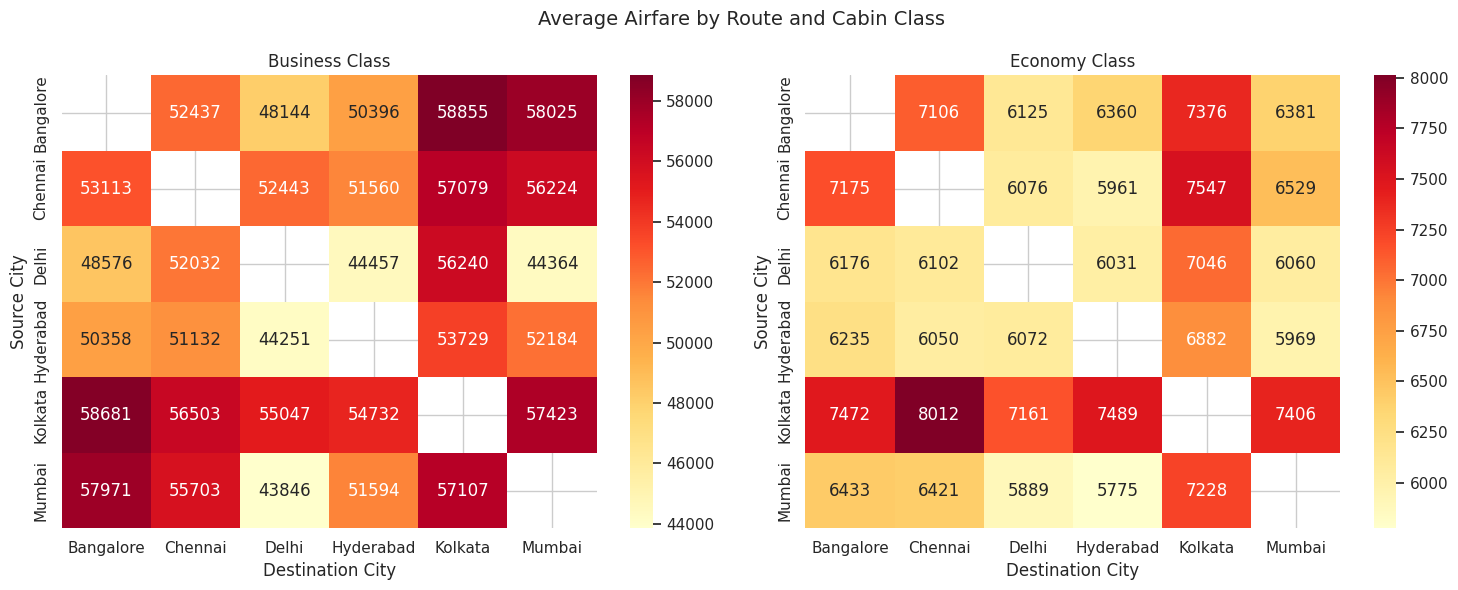

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, cabin_class in zip(axes, ["Business", "Economy"]):
    heatmap_data = (
        df[df["class"] == cabin_class]
        .pivot_table(
            index="source_city",
            columns="destination_city",
            values="price",
            aggfunc="mean"
        )
    )

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".0f",
        cmap="YlOrRd",
        ax=ax
    )

    ax.set_title(f"{cabin_class} Class")
    ax.set_xlabel("Destination City")
    ax.set_ylabel("Source City")

plt.suptitle(
    "Average Airfare by Route and Cabin Class",
    fontsize=14
)

plt.tight_layout()
plt.show()

#### Key Finding

Airfares varied substantially across the 30 directional routes. In business
class, Bangalore to Kolkata had the highest observed average fare at INR 58,855,
while Mumbai to Delhi had the lowest at INR 43,846, a difference of 34.2%.

In economy class, Kolkata to Chennai had the highest average fare at INR 8,012,
while Mumbai to Hyderabad had the lowest at INR 5,775, a difference of 38.7%.
Routes involving Kolkata generally appeared among the higher-priced markets.

Fares also differed between opposite directions of the same city pair,
suggesting that route direction should be treated as a distinct feature rather
than combining both directions into one market.

## Predictive Modeling

### Objective

A Random Forest regression model is developed to estimate airfare using
booking window, airline, route, cabin class, departure and arrival time,
number of stops, and flight duration.

The flight-number identifier is excluded because it has high cardinality and
may encourage the model to memorize individual services rather than learn
generalizable pricing patterns.

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [28]:
model_features = [
    "airline",
    "source_city",
    "destination_city",
    "departure_time",
    "stops",
    "arrival_time",
    "class",
    "duration",
    "days_left"
]

X = df[model_features]
y = df["price"]

categorical_features = [
    "airline",
    "source_city",
    "destination_city",
    "departure_time",
    "stops",
    "arrival_time",
    "class"
]

numeric_features = [
    "duration",
    "days_left"
]

print("Features used:", model_features)
print(f"Dataset size: {len(X):,} observations")

Features used: ['airline', 'source_city', 'destination_city', 'departure_time', 'stops', 'arrival_time', 'class', 'duration', 'days_left']
Dataset size: 300,153 observations


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=df["class"]
)

print(f"Training observations: {len(X_train):,}")
print(f"Testing observations: {len(X_test):,}")

Training observations: 240,122
Testing observations: 60,031


In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

random_forest_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", random_forest_model)
    ]
)

In [31]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['airline', 'source_city',
                                                   'destination_city',
                                                   'departure_time', 'stops',
                                                   'arrival_time', 'class']),
                                                 ('numeric', 'passthrough',
                                                  ['duration', 'days_left'])])),
                ('model',
                 RandomForestRegressor(max_depth=20, min_samples_leaf=2,
                                       n_estimators=150, n_jobs=-1,
                                       random_state=42))])

In [32]:
y_pred = model_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE: INR {mae:,.0f}")
print(f"RMSE: INR {rmse:,.0f}")
print(f"R²: {r2:.4f}")

MAE: INR 1,297
RMSE: INR 2,792
R²: 0.9849


In [33]:
train_class_medians = (
    pd.DataFrame({
        "class": X_train["class"],
        "price": y_train
    })
    .groupby("class")["price"]
    .median()
)

baseline_pred = X_test["class"].map(train_class_medians)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = mean_squared_error(y_test, baseline_pred) ** 0.5
baseline_r2 = r2_score(y_test, baseline_pred)

print(f"Class-Median Baseline MAE: INR {baseline_mae:,.0f}")
print(f"Class-Median Baseline RMSE: INR {baseline_rmse:,.0f}")
print(f"Class-Median Baseline R²: {baseline_r2:.4f}")

Class-Median Baseline MAE: INR 4,824
Class-Median Baseline RMSE: INR 7,950
Class-Median Baseline R²: 0.8776


In [34]:
mae_improvement = (
    (baseline_mae - mae) / baseline_mae * 100
)

rmse_improvement = (
    (baseline_rmse - rmse) / baseline_rmse * 100
)

print(f"MAE Improvement over Baseline: {mae_improvement:.1f}%")
print(f"RMSE Improvement over Baseline: {rmse_improvement:.1f}%")

MAE Improvement over Baseline: 73.1%
RMSE Improvement over Baseline: 64.9%


In [35]:
results = X_test.copy()

results["actual_price"] = y_test
results["predicted_price"] = y_pred
results["absolute_error"] = abs(
    results["actual_price"] - results["predicted_price"]
)

class_model_performance = (
    results.groupby("class")
    .apply(
        lambda group: pd.Series({
            "observations": len(group),
            "MAE": mean_absolute_error(
                group["actual_price"],
                group["predicted_price"]
            ),
            "RMSE": mean_squared_error(
                group["actual_price"],
                group["predicted_price"]
            ) ** 0.5,
            "R2": r2_score(
                group["actual_price"],
                group["predicted_price"]
            )
        }),
        include_groups=False
    )
    .round(2)
)

class_model_performance

,observations,MAE,RMSE,R2
class,,,,
Business,18698.0,2441.99,4491.75,0.88
Economy,41333.0,778.42,1482.02,0.84


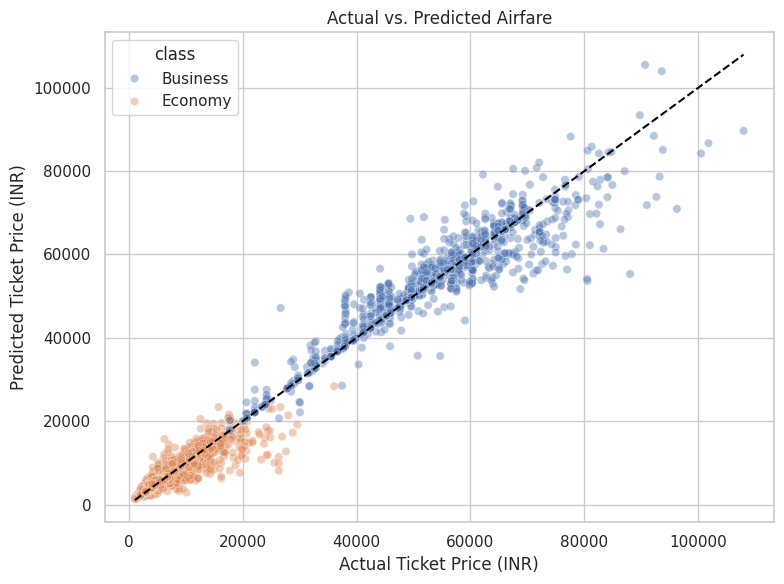

In [36]:
plot_sample = results.sample(
    n=5000,
    random_state=42
)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=plot_sample,
    x="actual_price",
    y="predicted_price",
    hue="class",
    alpha=0.4
)

minimum_price = min(
    plot_sample["actual_price"].min(),
    plot_sample["predicted_price"].min()
)

maximum_price = max(
    plot_sample["actual_price"].max(),
    plot_sample["predicted_price"].max()
)

plt.plot(
    [minimum_price, maximum_price],
    [minimum_price, maximum_price],
    linestyle="--",
    color="black",
    label="Perfect Prediction"
)

plt.title("Actual vs. Predicted Airfare")
plt.xlabel("Actual Ticket Price (INR)")
plt.ylabel("Predicted Ticket Price (INR)")
plt.tight_layout()
plt.show()

#### Initial Model Performance

The Random Forest model achieved a mean absolute error (MAE) of INR 1,297, a root mean squared error (RMSE) of INR 2,792, and an R² of 0.9849 on the held-out test set. This means the model explained approximately 98.5% of the overall variation in observed ticket prices; R² should not be interpreted as prediction accuracy.

To determine whether this performance resulted primarily from the large price difference between economy and business class, the Random Forest was compared with a class-median baseline. The baseline produced an MAE of INR 4,824, an RMSE of INR 7,950, and an R² of 0.8776. The Random Forest reduced MAE by 73.1% and RMSE by 64.9%, demonstrating that airline, route, booking window, stops, departure and arrival time, and flight duration provided substantial predictive value beyond cabin class alone.

Performance remained strong when evaluated separately by cabin class. For economy tickets, the model achieved an MAE of INR 778, an RMSE of INR 1,482, and an R² of 0.84. For business-class tickets, it achieved an MAE of INR 2,442, an RMSE of INR 4,492, and an R² of 0.88. The higher absolute error for business class is consistent with its substantially higher and more variable ticket prices.

The actual-versus-predicted plot shows that most observations fall near the perfect-prediction line. Prediction errors increase among the highest-priced business-class tickets, where the model sometimes underestimates unusually expensive fares. This indicates that the model captures general pricing patterns effectively but is less precise for extreme premium fares.

Because the dataset was randomly divided into training and test observations, repeated services may appear in both subsets even though flight number was excluded from the model features. The reported performance therefore represents interpolation within the observed market and should not be interpreted as guaranteed performance on future periods or entirely new airline markets.

### Feature Importance

Permutation importance is used to measure how much the model's prediction error
increases when each feature is randomly shuffled. A larger increase in MAE
indicates that the model relies more heavily on that feature.

This method evaluates predictive importance rather than causality. Correlated
features may share or redistribute importance.

In [37]:
from sklearn.inspection import permutation_importance

importance_sample = X_test.sample(
    n=5000,
    random_state=42
)

importance_target = y_test.loc[
    importance_sample.index
]

permutation_results = permutation_importance(
    model_pipeline,
    importance_sample,
    importance_target,
    scoring="neg_mean_absolute_error",
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [38]:
feature_importance = pd.DataFrame({
    "feature": model_features,
    "mae_increase": permutation_results.importances_mean,
    "importance_std": permutation_results.importances_std
})

feature_importance = feature_importance.sort_values(
    "mae_increase",
    ascending=False
).reset_index(drop=True)

feature_importance[
    ["mae_increase", "importance_std"]
] = feature_importance[
    ["mae_increase", "importance_std"]
].round(1)

feature_importance

,feature,mae_increase,importance_std
0,class,18458.4,273.0
1,duration,3276.6,34.9
2,source_city,1895.4,22.4
3,airline,1893.5,15.5
4,destination_city,1802.3,25.3
5,days_left,1534.6,27.8
6,arrival_time,713.6,16.9
7,departure_time,570.0,19.6
8,stops,434.0,3.7


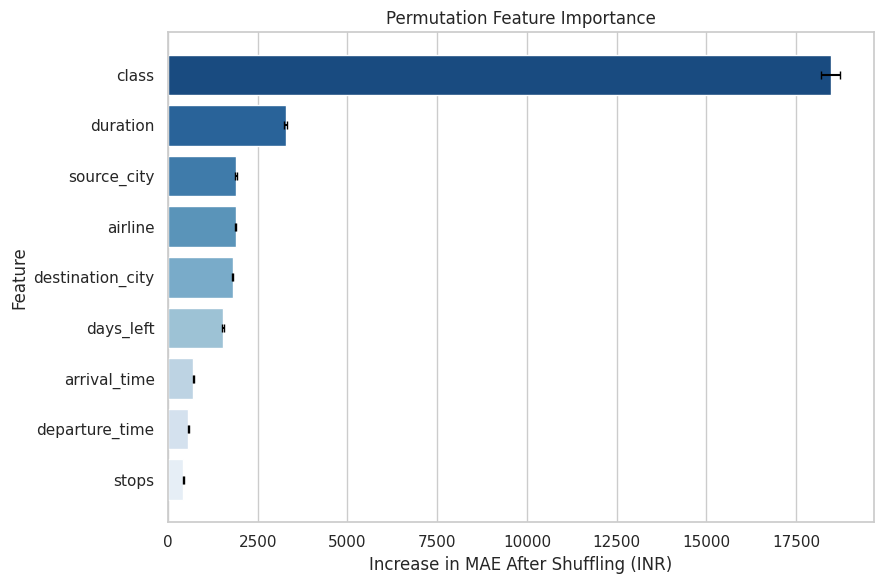

In [39]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=feature_importance,
    x="mae_increase",
    y="feature",
    hue="feature",
    palette="Blues_r",
    legend=False
)

plt.errorbar(
    x=feature_importance["mae_increase"],
    y=range(len(feature_importance)),
    xerr=feature_importance["importance_std"],
    fmt="none",
    color="black",
    capsize=3
)

plt.title("Permutation Feature Importance")
plt.xlabel("Increase in MAE After Shuffling (INR)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [40]:
top_five_features = feature_importance.head(5)

top_five_features

,feature,mae_increase,importance_std
0,class,18458.4,273.0
1,duration,3276.6,34.9
2,source_city,1895.4,22.4
3,airline,1893.5,15.5
4,destination_city,1802.3,25.3


#### Key Finding

Cabin class was the most influential feature by a substantial margin. Randomly shuffling the class variable increased the model's MAE by approximately INR 18,458, confirming that the distinction between economy and business class is the primary driver of ticket-price variation in this dataset.

Flight duration ranked second, increasing MAE by approximately INR 3,277 when shuffled. Origin city, airline, and destination city followed, each increasing MAE by approximately INR 1,800–1,900. These results indicate that itinerary characteristics and carrier selection provide meaningful predictive information beyond cabin class.

Booking timing also remained important. Shuffling `days_left` increased MAE by approximately INR 1,535, supporting the earlier finding that fares, particularly economy fares, rise as departure approaches.

Arrival time and departure time showed smaller but measurable contributions. The number of stops had the lowest standalone permutation importance, increasing MAE by approximately INR 434. This does not mean that stops are unrelated to price. Stops are strongly associated with flight duration, so part of their predictive information may already be captured by the duration variable.

Permutation importance measures the model's reliance on each feature rather than a causal effect. The values should therefore be interpreted as predictive contributions within this dataset, not as evidence that changing a feature would directly cause the corresponding change in airfare.


### Robustness Check: Grouped Holdout by Flight Number

The initial model used a random train-test split, which may place observations
from the same flight number in both subsets. To test generalization more
strictly, a grouped holdout is conducted so that each flight number appears
exclusively in either the training set or the test set.

Flight number remains excluded from the predictor variables and is used only
to define the split.

In [41]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.base import clone

group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

group_train_index, group_test_index = next(
    group_split.split(
        X,
        y,
        groups=df["flight"]
    )
)

X_train_grouped = X.iloc[group_train_index]
X_test_grouped = X.iloc[group_test_index]

y_train_grouped = y.iloc[group_train_index]
y_test_grouped = y.iloc[group_test_index]

train_flights = set(
    df.iloc[group_train_index]["flight"]
)

test_flights = set(
    df.iloc[group_test_index]["flight"]
)

flight_overlap = train_flights.intersection(test_flights)

print(f"Training observations: {len(X_train_grouped):,}")
print(f"Testing observations: {len(X_test_grouped):,}")
print(f"Training flight numbers: {len(train_flights):,}")
print(f"Testing flight numbers: {len(test_flights):,}")
print(f"Overlapping flight numbers: {len(flight_overlap)}")

Training observations: 245,189
Testing observations: 54,964
Training flight numbers: 1,248
Testing flight numbers: 313
Overlapping flight numbers: 0


In [42]:
grouped_class_distribution = pd.DataFrame({
    "Training": X_train_grouped["class"].value_counts(normalize=True),
    "Testing": X_test_grouped["class"].value_counts(normalize=True)
}).round(4)

grouped_class_distribution

,Training,Testing
class,,
Economy,0.6869,0.6956
Business,0.3131,0.3044


In [43]:
grouped_model_pipeline = clone(model_pipeline)

grouped_model_pipeline.fit(
    X_train_grouped,
    y_train_grouped
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['airline', 'source_city',
                                                   'destination_city',
                                                   'departure_time', 'stops',
                                                   'arrival_time', 'class']),
                                                 ('numeric', 'passthrough',
                                                  ['duration', 'days_left'])])),
                ('model',
                 RandomForestRegressor(max_depth=20, min_samples_leaf=2,
                                       n_estimators=150, n_jobs=-1,
                                       random_state=42))])

In [44]:
grouped_pred = grouped_model_pipeline.predict(
    X_test_grouped
)

grouped_mae = mean_absolute_error(
    y_test_grouped,
    grouped_pred
)

grouped_rmse = mean_squared_error(
    y_test_grouped,
    grouped_pred
) ** 0.5

grouped_r2 = r2_score(
    y_test_grouped,
    grouped_pred
)

print(f"Grouped Holdout MAE: INR {grouped_mae:,.0f}")
print(f"Grouped Holdout RMSE: INR {grouped_rmse:,.0f}")
print(f"Grouped Holdout R²: {grouped_r2:.4f}")

Grouped Holdout MAE: INR 2,898
Grouped Holdout RMSE: INR 5,278
Grouped Holdout R²: 0.9449


In [45]:
validation_comparison = pd.DataFrame({
    "Validation Method": [
        "Random Split",
        "Grouped Holdout by Flight Number"
    ],
    "MAE": [
        mae,
        grouped_mae
    ],
    "RMSE": [
        rmse,
        grouped_rmse
    ],
    "R2": [
        r2,
        grouped_r2
    ]
})

validation_comparison[
    ["MAE", "RMSE"]
] = validation_comparison[
    ["MAE", "RMSE"]
].round(0)

validation_comparison["R2"] = (
    validation_comparison["R2"].round(4)
)

validation_comparison

,Validation Method,MAE,RMSE,R2
0,Random Split,1297.0,2792.0,0.9849
1,Grouped Holdout by Flight Number,2898.0,5278.0,0.9449


#### Robustness Check Results

The grouped holdout assigned 1,248 flight numbers to the training set and 313 different flight numbers to the test set, with no overlap between the two groups. Cabin-class distributions remained comparable, with economy observations representing 68.7% of the training set and 69.6% of the test set.

Under this stricter validation design, the model achieved an MAE of INR 2,898, an RMSE of INR 5,278, and an R² of 0.9449. Performance was lower than under the random split, which produced an MAE of INR 1,297, an RMSE of INR 2,792, and an R² of 0.9849. This decline indicates that the random split provided an optimistic estimate because similar flight services could appear in both subsets.

Nevertheless, the model continued to explain approximately 94.5% of observed price variation for flight numbers that were entirely excluded from training. The grouped result provides stronger evidence that the model learned general pricing relationships associated with cabin class, duration, airline, route, and booking window rather than merely memorizing individual flight services.

Because the dataset does not contain observation dates or a separate future collection period, this grouped holdout evaluates generalization to unseen flight numbers within the same market rather than future airfare forecasting.


## Dashboard Data Preparation

The cleaned dataset is exported with engineered route and booking-window
features for development of an interactive Tableau dashboard.

In [46]:
tableau_columns = [
    "airline",
    "flight",
    "source_city",
    "destination_city",
    "route",
    "departure_time",
    "arrival_time",
    "stops",
    "class",
    "duration",
    "days_left",
    "days_left_group",
    "price"
]

tableau_data = df[tableau_columns].copy()

tableau_data.to_csv(
    "/tableau_airfare_data.csv",
    index=False
)

print(f"Exported rows: {len(tableau_data):,}")
print(f"Exported columns: {tableau_data.shape[1]}")
tableau_data.head()

Exported rows: 300,153
Exported columns: 13


,airline,flight,source_city,destination_city,route,departure_time,arrival_time,stops,class,duration,days_left,days_left_group,price
0,SpiceJet,SG-8709,Delhi,Mumbai,Delhi → Mumbai,Evening,Night,zero,Economy,2.17,1,1–7,5953
1,SpiceJet,SG-8157,Delhi,Mumbai,Delhi → Mumbai,Early_Morning,Morning,zero,Economy,2.33,1,1–7,5953
2,AirAsia,I5-764,Delhi,Mumbai,Delhi → Mumbai,Early_Morning,Early_Morning,zero,Economy,2.17,1,1–7,5956
3,Vistara,UK-995,Delhi,Mumbai,Delhi → Mumbai,Morning,Afternoon,zero,Economy,2.25,1,1–7,5955
4,Vistara,UK-963,Delhi,Mumbai,Delhi → Mumbai,Morning,Morning,zero,Economy,2.33,1,1–7,5955


In [47]:
from google.colab import files

files.download("/tableau_airfare_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Historical Buy Now / Hold Signal

A historical decision signal was created for Tableau using the model’s predicted fares.

For each flight, route, cabin class, and current booking window, the current predicted fare is compared with the lowest predicted fare available in the remaining booking windows.

* **Buy Now:** The current predicted fare is within 5% of the lowest remaining predicted fare.
* **Hold:** A remaining booking window has a predicted fare that is more than 5% lower than the current predicted fare.

The exported dataset contains 4,256 aggregated booking-window records across 238 eligible unseen flight numbers and 30 directional routes.

The signal is intended for historical scenario exploration only. It is not connected to live airfare data and should not be interpreted as real-time purchasing advice.


In [51]:
# Step 6A — Create the historical Buy Now / Hold signal dataset

from google.colab import files

signal_df = booking_window_results.copy()

signal_df["booking_window"] = (
    signal_df["days_left_group"]
    .astype(str)
    .str.replace("–", "-", regex=False)
)

window_order = {
    "1-7": 1,
    "8-14": 2,
    "15-21": 3,
    "22-30": 4,
    "31-40": 5,
    "41-49": 6
}

signal_df["window_order"] = (
    signal_df["booking_window"].map(window_order)
)

signal_df["route"] = (
    signal_df["source_city"]
    + " to "
    + signal_df["destination_city"]
)

signal_df = signal_df.sort_values(
    decision_columns + ["window_order"]
).reset_index(drop=True)

signal_records = []

for _, group in signal_df.groupby(decision_columns):
    group = group.sort_values("window_order").copy()

    for row_index, row in group.iterrows():
        remaining_windows = group.loc[
            group["window_order"] <= row["window_order"]
        ]

        best_index = remaining_windows["predicted_fare"].idxmin()
        best_remaining_fare = signal_df.loc[
            best_index,
            "predicted_fare"
        ]
        best_remaining_window = signal_df.loc[
            best_index,
            "booking_window"
        ]

        opportunity_gap_pct = (
            (row["predicted_fare"] - best_remaining_fare)
            / best_remaining_fare
            * 100
        )

        signal = (
            "Buy Now"
            if opportunity_gap_pct <= 5
            else "Hold"
        )

        record = row.to_dict()
        record["best_remaining_window"] = best_remaining_window
        record["best_remaining_predicted_fare"] = best_remaining_fare
        record["opportunity_gap_pct"] = opportunity_gap_pct
        record["signal"] = signal

        signal_records.append(record)

purchase_timing_signal = pd.DataFrame(signal_records)

export_columns = [
    "flight",
    "airline",
    "source_city",
    "destination_city",
    "route",
    "class",
    "booking_window",
    "window_order",
    "actual_fare",
    "predicted_fare",
    "best_remaining_window",
    "best_remaining_predicted_fare",
    "opportunity_gap_pct",
    "signal",
    "observations"
]

purchase_timing_signal = (
    purchase_timing_signal[export_columns]
    .sort_values(
        [
            "class",
            "route",
            "flight",
            "window_order"
        ]
    )
    .reset_index(drop=True)
)

signal_summary = (
    purchase_timing_signal["signal"]
    .value_counts()
    .rename_axis("signal")
    .reset_index(name="records")
)

print(
    f"Exported records: "
    f"{len(purchase_timing_signal):,}"
)
print(
    f"Flight numbers: "
    f"{purchase_timing_signal['flight'].nunique():,}"
)
print(
    f"Routes: "
    f"{purchase_timing_signal['route'].nunique():,}"
)

display(signal_summary)
display(purchase_timing_signal.head())

file_name = "purchase_timing_signal.csv"
purchase_timing_signal.to_csv(
    file_name,
    index=False
)

files.download(file_name)

Exported records: 4,256
Flight numbers: 238
Routes: 30


,signal,records
0,Buy Now,4015
1,Hold,241


,flight,airline,source_city,destination_city,route,class,booking_window,window_order,actual_fare,predicted_fare,best_remaining_window,best_remaining_predicted_fare,opportunity_gap_pct,signal,observations
0,AI-503,Air_India,Bangalore,Chennai,Bangalore to Chennai,Business,1-7,1,63087.6,49358.934705,1-7,49358.934705,0.000000,Buy Now,5
1,AI-503,Air_India,Bangalore,Chennai,Bangalore to Chennai,Business,15-21,3,60396.0,47939.903587,15-21,47939.903587,0.000000,Buy Now,14
2,AI-503,Air_India,Bangalore,Chennai,Bangalore to Chennai,Business,22-30,4,60396.0,47937.486185,22-30,47937.486185,0.000000,Buy Now,18
3,AI-503,Air_India,Bangalore,Chennai,Bangalore to Chennai,Business,31-40,5,60396.0,48002.161928,22-30,47937.486185,0.134917,Buy Now,20
4,AI-503,Air_India,Bangalore,Chennai,Bangalore to Chennai,Business,41-49,6,60396.0,48152.324281,22-30,47937.486185,0.448163,Buy Now,16


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Historical Purchase-Timing Policy Evaluation

The model was evaluated as a historical booking-window decision tool using the grouped holdout set. This test set contains 54,964 observations from 313 flight numbers that were not present during model training.

For each observation, the trained Random Forest generated a predicted fare. The original flight number and actual fare were then restored using the test-set indices. These records form the basis of the historical policy simulation.

This evaluation should not be interpreted as a real-time pricing experiment because the dataset is cross-sectional rather than a longitudinal record of repeated fare observations for the same ticket.


In [48]:
# Step 7A — Build the grouped-holdout backtest dataset

required_columns = {
    "flight",
    "airline",
    "source_city",
    "destination_city",
    "class",
    "days_left",
    "price"
}

candidate_frames = {
    name: obj
    for name, obj in globals().items()
    if isinstance(obj, pd.DataFrame)
    and required_columns.issubset(obj.columns)
}

if not candidate_frames:
    raise ValueError(
        "No source dataframe was found with all required columns: "
        "flight, airline, source_city, destination_city, "
        "class, days_left, and price."
    )

data_name, airfare_df = max(
    candidate_frames.items(),
    key=lambda item: len(item[1])
)

backtest_df = airfare_df.loc[X_test_grouped.index].copy()

backtest_df["predicted_price"] = (
    grouped_model_pipeline.predict(X_test_grouped)
)

if "days_left_group" not in backtest_df.columns:
    backtest_df["days_left_group"] = pd.cut(
        backtest_df["days_left"],
        bins=[0, 7, 14, 21, 30, 40, 49],
        labels=[
            "1-7",
            "8-14",
            "15-21",
            "22-30",
            "31-40",
            "41-49"
        ],
        include_lowest=True
    )

print(f"Source dataframe: {data_name}")
print(f"Backtest observations: {len(backtest_df):,}")
print(
    f"Unseen flight numbers: "
    f"{backtest_df['flight'].nunique():,}"
)
print(
    f"Actual mean fare: "
    f"INR {backtest_df['price'].mean():,.0f}"
)
print(
    f"Predicted mean fare: "
    f"INR {backtest_df['predicted_price'].mean():,.0f}"
)

backtest_df[
    [
        "flight",
        "source_city",
        "destination_city",
        "class",
        "days_left",
        "days_left_group",
        "price",
        "predicted_price"
    ]
].head()

Source dataframe: df
Backtest observations: 54,964
Unseen flight numbers: 313
Actual mean fare: INR 20,393
Predicted mean fare: INR 20,122


,flight,source_city,destination_city,class,days_left,days_left_group,price,predicted_price
2,I5-764,Delhi,Mumbai,Economy,1,1–7,5956,6328.009027
21,G8-101,Delhi,Mumbai,Economy,1,1–7,5954,11614.587839
24,6E-5328,Delhi,Mumbai,Economy,1,1–7,6165,7916.492587
41,AI-502,Delhi,Mumbai,Economy,1,1–7,12150,13118.116027
55,6E-2168,Delhi,Mumbai,Economy,1,1–7,13279,14263.986640


### Model-Guided Policy versus Random Booking Timing

Each decision unit is defined by flight number, airline, origin, destination, and cabin class. Observations are aggregated into six booking windows:

* 1–7 days
* 8–14 days
* 15–21 days
* 22–30 days
* 31–40 days
* 41–49 days

The **model-guided policy** selects the booking window with the lowest predicted average fare. The selected window is evaluated using its corresponding actual average fare.

The **random-timing policy** represents an equal-probability choice among the available booking windows. Its expected fare is calculated as the average actual fare across those windows.

Savings are calculated as:

**Savings Rate = (Random-Timing Fare − Model-Guided Fare) / Random-Timing Fare**


In [49]:
# Step 7B — Compare model-guided and random booking policies

decision_columns = [
    "flight",
    "airline",
    "source_city",
    "destination_city",
    "class"
]

booking_window_results = (
    backtest_df
    .dropna(subset=["days_left_group"])
    .groupby(
        decision_columns + ["days_left_group"],
        observed=True
    )
    .agg(
        actual_fare=("price", "mean"),
        predicted_fare=("predicted_price", "mean"),
        observations=("price", "size")
    )
    .reset_index()
)

window_counts = (
    booking_window_results
    .groupby(decision_columns)
    .size()
    .rename("available_windows")
    .reset_index()
)

eligible_units = window_counts.loc[
    window_counts["available_windows"] >= 2,
    decision_columns
]

booking_window_results = booking_window_results.merge(
    eligible_units,
    on=decision_columns,
    how="inner"
)

model_choice_index = (
    booking_window_results
    .groupby(decision_columns)["predicted_fare"]
    .idxmin()
)

model_policy = (
    booking_window_results
    .loc[
        model_choice_index,
        decision_columns
        + ["days_left_group", "actual_fare", "predicted_fare"]
    ]
    .rename(
        columns={
            "days_left_group": "recommended_window",
            "actual_fare": "model_policy_fare",
            "predicted_fare": "recommended_predicted_fare"
        }
    )
)

random_policy = (
    booking_window_results
    .groupby(decision_columns, as_index=False)
    .agg(
        random_policy_fare=("actual_fare", "mean"),
        available_windows=("days_left_group", "size")
    )
)

policy_results = model_policy.merge(
    random_policy,
    on=decision_columns,
    how="inner"
)

policy_results["savings_inr"] = (
    policy_results["random_policy_fare"]
    - policy_results["model_policy_fare"]
)

policy_results["savings_pct"] = (
    policy_results["savings_inr"]
    / policy_results["random_policy_fare"]
    * 100
)

overall_model_fare = policy_results["model_policy_fare"].mean()
overall_random_fare = policy_results["random_policy_fare"].mean()
overall_savings_inr = overall_random_fare - overall_model_fare
overall_savings_pct = (
    overall_savings_inr / overall_random_fare * 100
)

print(f"Eligible booking decisions: {len(policy_results):,}")
print(f"Random-timing average fare: INR {overall_random_fare:,.0f}")
print(f"Model-guided average fare: INR {overall_model_fare:,.0f}")
print(f"Average savings: INR {overall_savings_inr:,.0f}")
print(f"Average savings rate: {overall_savings_pct:.2f}%")

policy_summary_by_class = (
    policy_results
    .groupby("class")
    .agg(
        booking_decisions=("flight", "size"),
        random_timing_fare=("random_policy_fare", "mean"),
        model_guided_fare=("model_policy_fare", "mean"),
        average_savings_inr=("savings_inr", "mean"),
        average_savings_pct=("savings_pct", "mean")
    )
    .round(2)
)

policy_summary_by_class

Eligible booking decisions: 756
Random-timing average fare: INR 15,225
Model-guided average fare: INR 13,679
Average savings: INR 1,545
Average savings rate: 10.15%


,booking_decisions,random_timing_fare,model_guided_fare,average_savings_inr,average_savings_pct
class,,,,,
Business,166,46417.16,45874.86,542.31,1.19
Economy,590,6448.40,4621.01,1827.39,28.32


### Historical Simulation Results

To improve comparability, the strict evaluation retains only decision units with observations in all six booking windows. This produces 603 complete booking decisions from the grouped holdout sample.

| Segment  | Random-Timing Fare | Model-Guided Fare | Average Savings | Savings Rate |
| -------- | -----------------: | ----------------: | --------------: | -----------: |
| Overall  |         INR 17,043 |        INR 15,301 |       INR 1,742 |       10.22% |
| Business |         INR 46,568 |        INR 45,959 |         INR 609 |        1.31% |
| Economy  |          INR 6,650 |         INR 4,510 |       INR 2,141 |       32.19% |

A 5,000-iteration bootstrap produced the following 95% confidence intervals:

* Business: 0.83%–1.75%
* Economy: 30.79%–33.60%

**Business interpretation:** In a historical grouped-holdout simulation, the model-guided booking-window strategy reduced average business-class airfare by 1.31% relative to random booking timing.

**Economy interpretation:** In a historical grouped-holdout simulation, the model-guided booking-window strategy reduced average economy-class airfare by 32.19% relative to random booking timing.

These results describe historical associations and simulated policy performance. They do not guarantee equivalent savings for future or real-time purchases.


In [50]:
# Step 7C — Strict policy evaluation and bootstrap confidence intervals

import numpy as np

strict_policy_results = policy_results.loc[
    policy_results["available_windows"] == 6
].copy()

def summarize_policy(data):
    random_fare = data["random_policy_fare"].mean()
    model_fare = data["model_policy_fare"].mean()
    savings_inr = random_fare - model_fare
    savings_pct = savings_inr / random_fare * 100

    return pd.Series({
        "booking_decisions": len(data),
        "random_timing_fare": random_fare,
        "model_guided_fare": model_fare,
        "average_savings_inr": savings_inr,
        "savings_rate_pct": savings_pct
    })

strict_overall_summary = summarize_policy(
    strict_policy_results
).to_frame().T

strict_class_summary = (
    strict_policy_results
    .groupby("class")
    .apply(summarize_policy, include_groups=False)
    .round(2)
)

rng = np.random.default_rng(42)
bootstrap_iterations = 5000
bootstrap_records = []

for cabin_class, class_data in strict_policy_results.groupby("class"):
    class_data = class_data.reset_index(drop=True)
    sample_size = len(class_data)

    bootstrap_savings = []

    for _ in range(bootstrap_iterations):
        sample_indices = rng.integers(
            0,
            sample_size,
            size=sample_size
        )

        sample = class_data.iloc[sample_indices]

        random_fare = sample["random_policy_fare"].mean()
        model_fare = sample["model_policy_fare"].mean()

        savings_pct = (
            (random_fare - model_fare)
            / random_fare
            * 100
        )

        bootstrap_savings.append(savings_pct)

    lower_ci, upper_ci = np.percentile(
        bootstrap_savings,
        [2.5, 97.5]
    )

    bootstrap_records.append({
        "class": cabin_class,
        "booking_decisions": sample_size,
        "savings_rate_pct": np.mean(bootstrap_savings),
        "ci_95_lower": lower_ci,
        "ci_95_upper": upper_ci
    })

bootstrap_summary = (
    pd.DataFrame(bootstrap_records)
    .set_index("class")
    .round(2)
)

print("Strict evaluation: all six booking windows required")
print(
    f"Eligible booking decisions: "
    f"{len(strict_policy_results):,}"
)

display(strict_overall_summary.round(2))
display(strict_class_summary)
display(bootstrap_summary)

Strict evaluation: all six booking windows required
Eligible booking decisions: 603


,booking_decisions,random_timing_fare,model_guided_fare,average_savings_inr,savings_rate_pct
0,603.0,17043.44,15301.48,1741.96,10.22


,booking_decisions,random_timing_fare,model_guided_fare,average_savings_inr,savings_rate_pct
class,,,,,
Business,157.0,46568.06,45958.66,609.39,1.31
Economy,446.0,6650.24,4509.60,2140.64,32.19


,booking_decisions,savings_rate_pct,ci_95_lower,ci_95_upper
class,,,,
Business,157,1.31,0.83,1.75
Economy,446,32.19,30.79,33.60


### Monte Carlo Simulation of Random Booking Timing

To directly simulate random booking behavior, the analysis retains 603 decision units with observations in all six booking windows.

In each simulation, one booking window is selected at random with equal probability for every decision unit. The resulting actual fares are averaged and compared with the average actual fare achieved by the model-guided policy.

This process is repeated 5,000 times to estimate:

* The average fare under random booking timing
* The average fare under the model-guided policy
* The average savings in INR
* The average percentage savings
* The 95% simulation interval for the savings rate

Unlike the preceding bootstrap analysis, which evaluates the sampling stability of the estimated savings, this Monte Carlo simulation directly represents repeated random booking-window choices.


In [53]:
# Step 7D — Monte Carlo simulation of random booking timing

strict_keys = (
    strict_policy_results[decision_columns]
    .drop_duplicates()
)

strict_window_data = booking_window_results.merge(
    strict_keys,
    on=decision_columns,
    how="inner"
)

actual_fare_matrix = (
    strict_window_data
    .pivot(
        index=decision_columns,
        columns="days_left_group",
        values="actual_fare"
    )
)

model_policy_fares = (
    strict_policy_results
    .set_index(decision_columns)["model_policy_fare"]
    .reindex(actual_fare_matrix.index)
)

simulation_rng = np.random.default_rng(42)
simulation_iterations = 5000

def run_random_timing_simulation(
    fare_matrix,
    model_fares,
    segment_name
):
    actual_values = fare_matrix.to_numpy()
    number_of_units, number_of_windows = actual_values.shape

    random_choices = simulation_rng.integers(
        0,
        number_of_windows,
        size=(simulation_iterations, number_of_units)
    )

    selected_random_fares = actual_values[
        np.arange(number_of_units)[None, :],
        random_choices
    ]

    random_average_fares = selected_random_fares.mean(axis=1)
    model_average_fare = model_fares.mean()

    savings_inr = (
        random_average_fares
        - model_average_fare
    )

    savings_pct = (
        savings_inr
        / random_average_fares
        * 100
    )

    return {
        "segment": segment_name,
        "booking_decisions": number_of_units,
        "simulations": simulation_iterations,
        "random_timing_fare": random_average_fares.mean(),
        "model_guided_fare": model_average_fare,
        "average_savings_inr": savings_inr.mean(),
        "average_savings_pct": savings_pct.mean(),
        "ci_95_lower": np.percentile(savings_pct, 2.5),
        "ci_95_upper": np.percentile(savings_pct, 97.5)
    }

monte_carlo_results = []

monte_carlo_results.append(
    run_random_timing_simulation(
        actual_fare_matrix,
        model_policy_fares,
        "Overall"
    )
)

for cabin_class in ["Business", "Economy"]:
    class_mask = (
        actual_fare_matrix.index
        .get_level_values("class")
        == cabin_class
    )

    monte_carlo_results.append(
        run_random_timing_simulation(
            actual_fare_matrix.loc[class_mask],
            model_policy_fares.loc[class_mask],
            cabin_class
        )
    )

monte_carlo_summary = (
    pd.DataFrame(monte_carlo_results)
    .set_index("segment")
    .round(2)
)

monte_carlo_summary

,booking_decisions,simulations,random_timing_fare,model_guided_fare,average_savings_inr,average_savings_pct,ci_95_lower,ci_95_upper
segment,,,,,,,,
Overall,603,5000,17041.78,15301.48,1740.29,10.21,9.14,11.30
Business,157,5000,46570.81,45958.66,612.14,1.31,0.67,2.03
Economy,446,5000,6654.00,4509.60,2144.40,32.20,29.53,34.77


### Monte Carlo Results and Business Interpretation

Across 5,000 Monte Carlo simulations, the random-timing policy produced an average fare of INR 17,042, compared with INR 15,301 under the model-guided policy. This corresponds to average simulated savings of INR 1,740, or 10.21%.

The 95% simulation interval for the overall savings rate was 9.14%–11.30%.

Results differed substantially by cabin class:

| Segment  | Random-Timing Fare | Model-Guided Fare | Average Savings | Savings Rate | 95% Simulation Interval |
| -------- | -----------------: | ----------------: | --------------: | -----------: | ----------------------: |
| Overall  |         INR 17,042 |        INR 15,301 |       INR 1,740 |       10.21% |            9.14%–11.30% |
| Business |         INR 46,571 |        INR 45,959 |         INR 612 |        1.31% |             0.67%–2.03% |
| Economy  |          INR 6,654 |         INR 4,510 |       INR 2,144 |       32.20% |           29.53%–34.77% |

**Business conclusion:** In a historical grouped-holdout simulation, the model-guided booking-window strategy reduced average airfare by 10.21% relative to random booking timing.

The estimated benefit was considerably larger for economy fares than for business-class fares. This result reflects a historical simulation based on cross-sectional airfare data and does not guarantee equivalent savings in future or real-time purchases.


In [52]:
purchase_timing_signal.loc[
    purchase_timing_signal["signal"] == "Hold",
    [
        "class",
        "route",
        "flight",
        "booking_window",
        "predicted_fare",
        "best_remaining_window",
        "best_remaining_predicted_fare",
        "opportunity_gap_pct"
    ]
].head(10)

,class,route,flight,booking_window,predicted_fare,best_remaining_window,best_remaining_predicted_fare,opportunity_gap_pct
20,Business,Bangalore to Chennai,UK-820,41-49,51309.613461,31-40,47764.738103,7.421532
62,Business,Bangalore to Delhi,AI-523,41-49,45044.080510,22-30,42531.124654,5.908510
152,Business,Bangalore to Kolkata,AI-516,41-49,36529.253020,15-21,31479.780171,16.040369
278,Business,Delhi to Bangalore,AI-542,41-49,41968.658111,22-30,37593.043859,11.639425
313,Business,Delhi to Bangalore,AI-811,31-40,47976.353624,22-30,44883.600963,6.890607
446,Business,Delhi to Kolkata,AI-678,41-49,45261.474572,22-30,42265.126744,7.089409
467,Business,Delhi to Kolkata,UK-705,15-21,40497.485206,8-14,38246.175238,5.886366
474,Business,Delhi to Kolkata,UK-727,22-30,32040.218657,8-14,29164.879503,9.858910
475,Business,Delhi to Kolkata,UK-727,31-40,31570.843070,8-14,29164.879503,8.249523
476,Business,Delhi to Kolkata,UK-727,41-49,31755.460180,8-14,29164.879503,8.882535
